<a href="https://colab.research.google.com/github/henriquebap/Machine_Learning_HB/blob/main/ML_Test_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle as p
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform

## Data Processing

### Load and processing

In [16]:
pickle_file_path = '/content/drive/MyDrive/ML test/mini_gm_public_v0.1.p'

In [17]:
try:
    with open(pickle_file_path, 'rb') as file:
        data = p.load(file)
        print("Data loaded successfully!")
except FileNotFoundError:
    print(f"File not found: {pickle_file_path}")
except p.UnpicklingError:
    print("Error unpickling the file. Ensure it is a valid pickle file.")
except Exception as e:
    print(f"Unexpected error: {e}")
    raise

# Validate the data structure
if not isinstance(data, dict):
    raise ValueError("The loaded data is not a dictionary as expected.")


Data loaded successfully!


In [ ]:
data

In [20]:
records = []
for syndrome_id, subjects in data.items():
    for subject_id, images in subjects.items():
        for image_id, embedding in images.items():
            records.append({
                "syndrome_id": syndrome_id,
                "subject_id": subject_id,
                "image_id": image_id,
                "embedding": embedding
            })
df = pd.DataFrame(records)
print(f"DataFrame created with {df.shape[0]} rows and {df.shape[1]} columns.")

DataFrame created with 1116 rows and 4 columns.


In [21]:
# Check for missing values
missing_summary = df.isnull().sum()
print("Missing values summary:")
print(missing_summary)

# Validate embedding dimensionality
invalid_embeddings = df[~df["embedding"].apply(lambda x: len(x) == 320)]
if not invalid_embeddings.empty:
    print(f"Found {invalid_embeddings.shape[0]} invalid embeddings (not 320 dimensions).")
    df = df[~df.index.isin(invalid_embeddings.index)]  # Remove invalid rows

# Remove duplicates
df = df.drop_duplicates(subset=["syndrome_id", "subject_id", "image_id"])
print(f"DataFrame after removing duplicates: {df.shape}")

# Sanity checks for syndrome_id
unique_syndromes = df["syndrome_id"].nunique()
print(f"Number of unique syndrome_ids: {unique_syndromes}")


Missing values summary:
syndrome_id    0
subject_id     0
image_id       0
embedding      0
dtype: int64
DataFrame after removing duplicates: (1116, 4)
Number of unique syndrome_ids: 10


In [27]:
# Summary statistics
syndrome_counts = df["syndrome_id"].value_counts()
print("Images per syndrome:")
print(syndrome_counts)

# Handle imbalances
low_count_syndromes = syndrome_counts[syndrome_counts < 10]
if not low_count_syndromes.empty:
    print("Syndromes with less than 10 samples:")
    print(low_count_syndromes)

# Save the preprocessed data
df.to_csv("preprocessed_data.csv", index=False)
print("Preprocessed data saved to 'preprocessed_data.csv'.")

Images per syndrome:
syndrome_id
300000034    210
300000080    198
100192430    136
300000007    115
300000082     98
100610443     89
300000018     74
100180860     67
100610883     65
700018215     64
Name: count, dtype: int64
Preprocessed data saved to 'preprocessed_data.csv'.


In [22]:
print("Number of syndromes:", df["syndrome_id"].nunique())
print("Images per syndrome:")
print(df.groupby("syndrome_id")["image_id"].count())

Number of syndromes: 10
Images per syndrome:
syndrome_id
100180860     67
100192430    136
100610443     89
100610883     65
300000007    115
300000018     74
300000034    210
300000080    198
300000082     98
700018215     64
Name: image_id, dtype: int64


### EDA (Exploratory Data Analysis)

In [28]:
# Dataset overview
print(f"Total records: {df.shape[0]}")
print(f"Unique syndrome IDs: {df['syndrome_id'].nunique()}")
print(f"Unique subject IDs: {df['subject_id'].nunique()}")
print(f"Unique image IDs: {df['image_id'].nunique()}")

Total records: 1116
Unique syndrome IDs: 10
Unique subject IDs: 941
Unique image IDs: 1116


Distribution of Images Per Syndrome

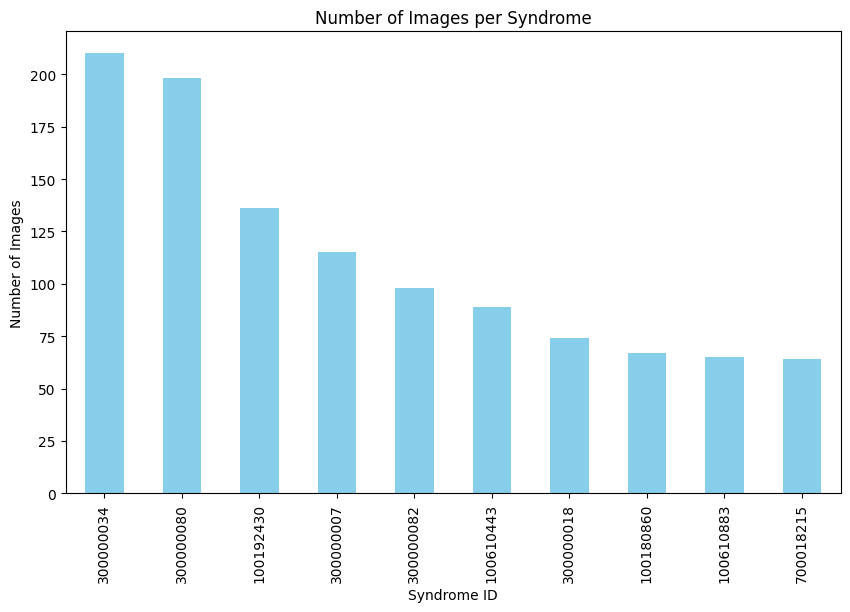

Syndromes with the most samples:
syndrome_id
300000034    210
300000080    198
100192430    136
300000007    115
300000082     98
Name: count, dtype: int64
Syndromes with the least samples:
syndrome_id
100610443    89
300000018    74
100180860    67
100610883    65
700018215    64
Name: count, dtype: int64


In [29]:
syndrome_counts = df["syndrome_id"].value_counts()

# Visualize the distribution
plt.figure(figsize=(10, 6))
syndrome_counts.plot(kind="bar", color="skyblue")
plt.title("Number of Images per Syndrome")
plt.xlabel("Syndrome ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

# Summary of the imbalance
print("Syndromes with the most samples:")
print(syndrome_counts.head())
print("Syndromes with the least samples:")
print(syndrome_counts.tail())

Analyze Embedding Features

t-SNE Clustering for Patterns

In [24]:
# Convert embeddings column to NumPy array
embeddings = np.array(df["embedding"].tolist())

# Check the number of samples
print(f"Number of samples: {embeddings.shape[0]}")

# Initialize t-SNE with appropriate parameters
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, embeddings.shape[0] - 1))

# Fit and transform the embeddings
tsne_results = tsne.fit_transform(embeddings)

# Add the t-SNE results to the DataFrame
df["tsne_x"], df["tsne_y"] = tsne_results[:, 0], tsne_results[:, 1]


Number of samples: 1116


In [30]:
# Summary statistics for embeddings
embedding_summary = {
    "Mean": np.mean(embeddings, axis=0),
    "Std Dev": np.std(embeddings, axis=0),
    "Min": np.min(embeddings, axis=0),
    "Max": np.max(embeddings, axis=0)
}

# Display overall statistics
print(f"Embedding Dimensionality: {embeddings.shape[1]}")
print(f"Overall Mean of Embeddings: {np.mean(embeddings):.4f}")
print(f"Overall Std Dev of Embeddings: {np.std(embeddings):.4f}")

Embedding Dimensionality: 320
Overall Mean of Embeddings: -0.0001
Overall Std Dev of Embeddings: 1.2336


Data Imbalances and Visualization:

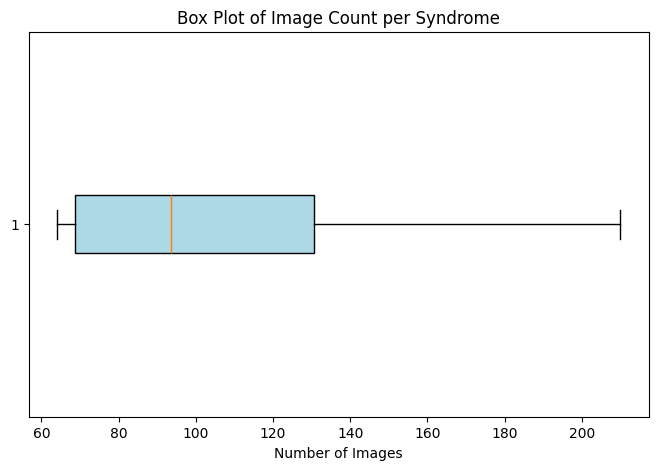

Syndromes with fewer than 10 samples:
Series([], Name: count, dtype: int64)


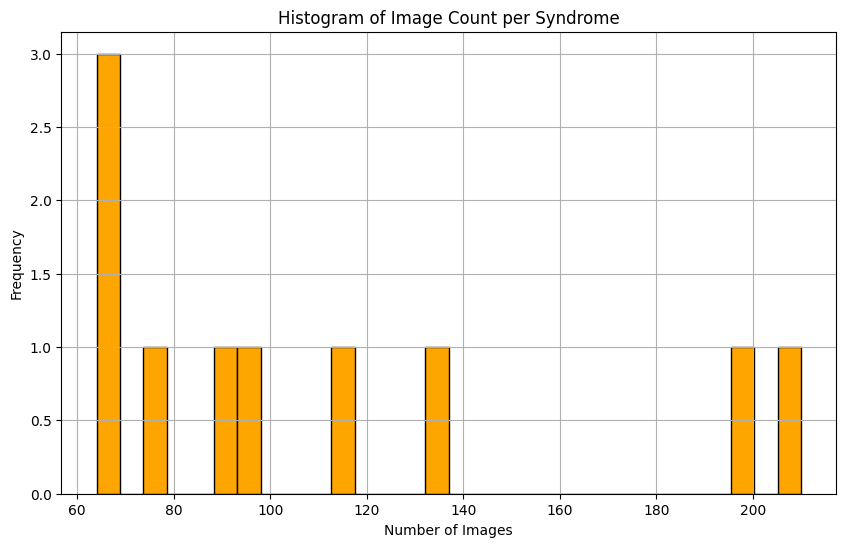

In [31]:
# Box plot for image count per syndrome
plt.figure(figsize=(8, 5))
plt.boxplot(syndrome_counts.values, vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Box Plot of Image Count per Syndrome")
plt.xlabel("Number of Images")
plt.show()

# Syndromes with very few samples
low_sample_syndromes = syndrome_counts[syndrome_counts < 10]
print("Syndromes with fewer than 10 samples:")
print(low_sample_syndromes)

# Visualize a histogram
plt.figure(figsize=(10, 6))
syndrome_counts.hist(bins=30, color="orange", edgecolor="black")
plt.title("Histogram of Image Count per Syndrome")
plt.xlabel("Number of Images")
plt.ylabel("Frequency")
plt.show()


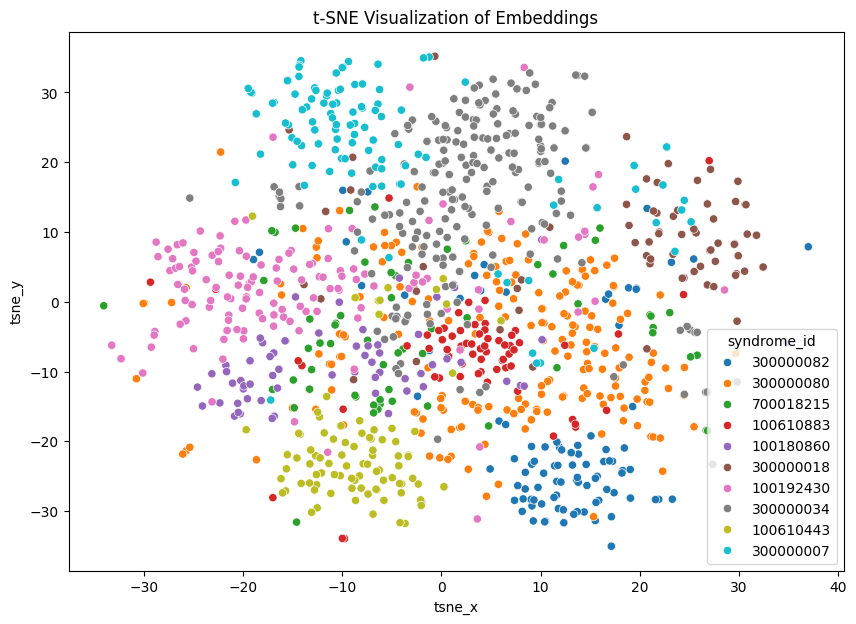

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x="tsne_x", y="tsne_y", hue="syndrome_id", data=df, palette="tab10")
plt.title("t-SNE Visualization of Embeddings")
plt.show()

In [34]:

# Compute pairwise distances (Euclidean)
pairwise_distances = squareform(pdist(embeddings, metric="euclidean"))

# Check distances for the first syndrome
syndrome_distances = pairwise_distances[df["syndrome_id"] == "300000082"]
print(f"Average distance for Syndrome '300000082': {np.mean(syndrome_distances):.4f}")


Average distance for Syndrome '300000082': 29.8443


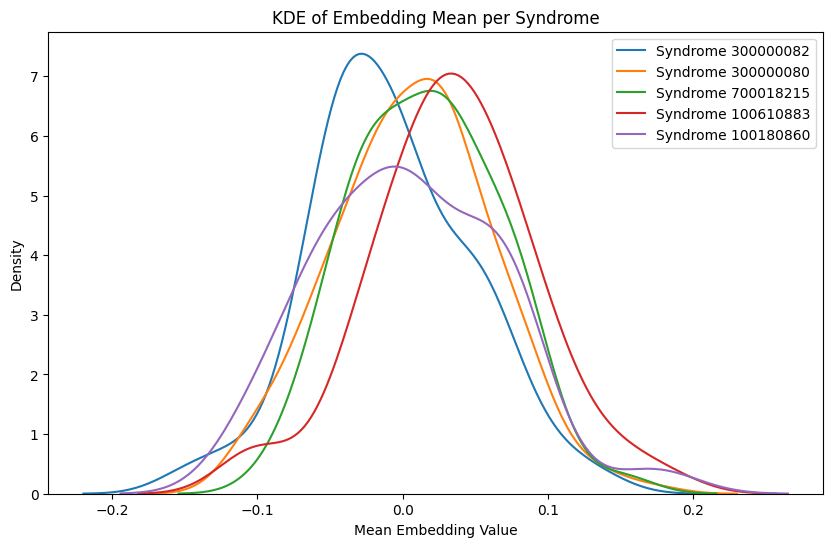

In [35]:
# KDE plots for the first few syndromes
syndromes_to_plot = df["syndrome_id"].unique()[:5]
plt.figure(figsize=(10, 6))

for syndrome in syndromes_to_plot:
    sns.kdeplot(
        np.mean(np.array(df[df["syndrome_id"] == syndrome]["embedding"].tolist()), axis=1),
        label=f"Syndrome {syndrome}"
    )

plt.title("KDE of Embedding Mean per Syndrome")
plt.xlabel("Mean Embedding Value")
plt.ylabel("Density")
plt.legend()
plt.show()

Data Visualization:

Number of unique syndromes: 10


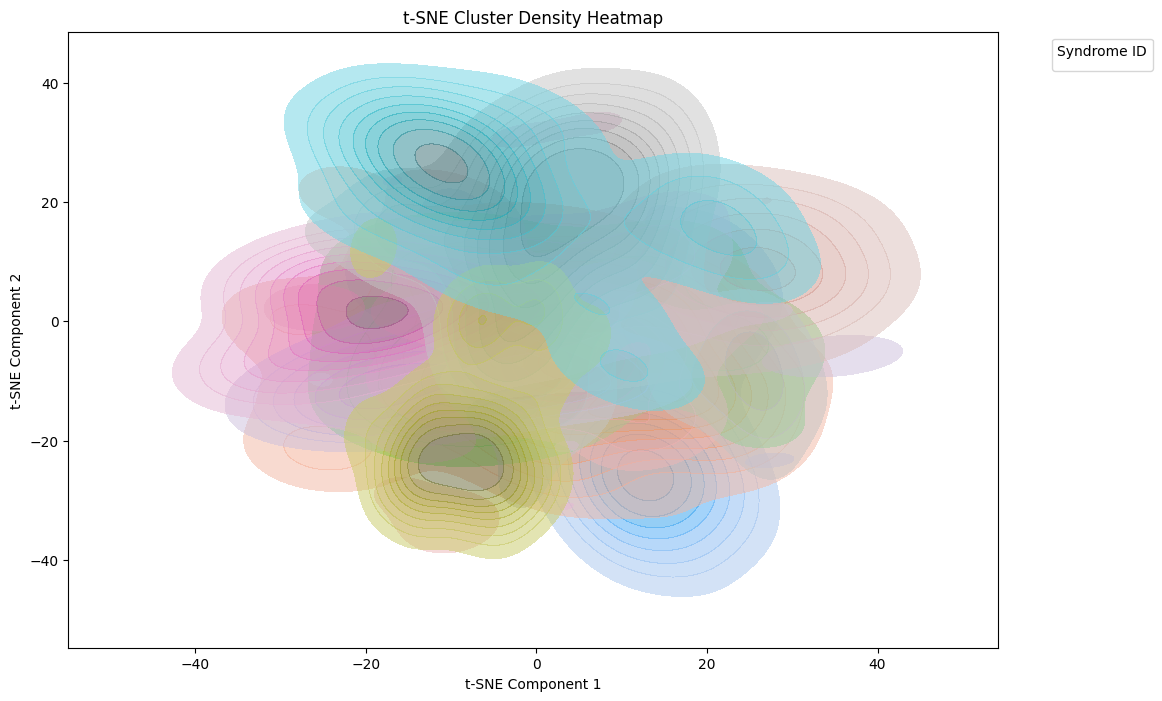

In [37]:
# Analyze clusters
unique_syndromes = df["syndrome_id"].nunique()
print(f"Number of unique syndromes: {unique_syndromes}")

# Identify overlapping regions using a density heatmap
plt.figure(figsize=(12, 8))
sns.kdeplot(
    x="tsne_x",
    y="tsne_y",
    hue="syndrome_id",
    data=df,
    fill=True,
    palette="tab10",
    alpha=0.5,
    levels=10
)
plt.title("t-SNE Cluster Density Heatmap")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Syndrome ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [38]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for t-SNE results
silhouette_avg = silhouette_score(embeddings, df["syndrome_id"])
print(f"Silhouette Score for t-SNE Clustering: {silhouette_avg:.4f}")


Silhouette Score for t-SNE Clustering: 0.0263
